### В данном файле:
1) получаем датасет(уже из csv-файл) 
2) Инициализируем classification-процессор
3) для одного и того же набора данных проводим обучение, вывод оценок и некоторую визуализацию на базе:
    * logistic_regression_softmax
    * logistic_regression_one_vs_rest
    * support_vector_machine
    * k_neighbors
    * decision_tree
    * random_forest
    * gradient_boosting 
4) сравниваем результаты, смотрим на переобучение(вроде нигде не было), точность и матрицу ошибок. У некоторых алгоритмов визуализируем важность признаков.
5) добавляем и анализируем затраты алгоритмов по времени и суммарно по памяти

*Выводы*: 
* все методы показали весьма неплохие результаты в точности модели не переобучившись; 
* случайный лес и бустинг предоставили количественно разные, но качественно схожие важности признаков; 
* дерево решений продемонстрировало интересную визуализация, полезную для понимания работы ряда алгоритмов. Но показало самую низкую точность. Возможно, проблема в парамертах
* даже на относительно небольших выборках (20000) методы могут занимать заметное время и быстро растущую (в зависимости от парамтров) потребляемую память
* для срабатывания некоторых алгоритмов пришлось корректировать дефолтные параметры. Например, для logistic_regression_softmax не хватило max_iter=100


In [ ]:
%pip install matplotlib scikit-learn

random_forest took 5.771 seconds

	A random forest classifier
Случайный лес — это мета-оценщик, который обучает ряд классификаторов на основе деревьев решений на различных подвыборках набора данных и использует усреднение для повышения точности прогнозирования и контроля переобучения

{'Accuracy': 0.9956,
 'OOB Score': 0.9936,
 'Матрица ошибок': [[1602, 5, 5], [6, 1764, 0], [6, 0, 1612]]}


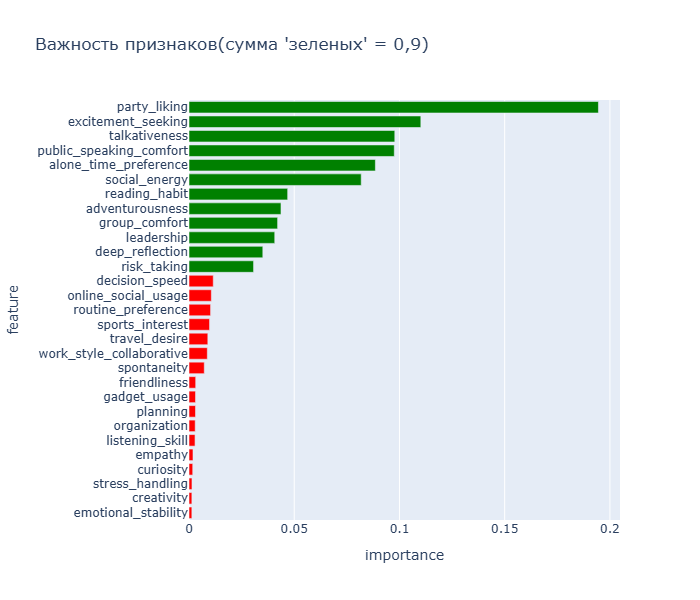

,precision,recall,f1-score,support
Ambivert,0.992565,0.993797,0.993180,1612.0000
Extrovert,0.997174,0.996610,0.996892,1770.0000
Introvert,0.996908,0.996292,0.996600,1618.0000
accuracy,0.995600,0.995600,0.995600,0.9956
macro avg,0.995549,0.995566,0.995557,5000.0000
weighted avg,0.995602,0.995600,0.995601,5000.0000


Memory Increased by: 60.75 MB


In [1]:
from private.utils import memory_check, prepare_personality_data
from public.models import ClassificationProcessor

with memory_check():
    df = prepare_personality_data()

    processor = ClassificationProcessor(df, "personality_type")

    processor.calculate(
            {
                # "logistic_regression_softmax" : {
                #     "test_size" : 0.2,
                #     "max_iter" : 200
                # },
                # "logistic_regression_one_vs_rest" : {
                #     "test_size" : 0.3
                # },
                # # "naive_bayes" : {},
                # "support_vector_machine" : {},
                # "k_neighbors" : {},
                # "decision_tree" : {},
                "random_forest" : {
                    "test_size" : 0.25,
                    "n_estimators" : 100
                },
                # "gradient_boosting" : {
                #     "n_estimators" : 100,
                #     "learning_rate" : 0.1,
                #     "max_depth" : 3
                # }
            }
    ).report()
